In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

from mcp_boltzmann import annihilation as ann
from mcp_boltzmann.boltzmann import MCPBoltzmann

warnings.filterwarnings("ignore")

In [53]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [54]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

### MCP model parameters

In [55]:
shelton_Q_mass_027 = load_csv('../input/fig/2206.13530_fig3_DNE_027.csv')
shelton_Q_of_M = interp1d(shelton_Q_mass_027[0], shelton_Q_mass_027[1])

In [56]:
MeV = 1
GeV = 1e3

In [57]:
# m_mcp = 10000.0*MeV
# m_mcp = 3150.0*MeV
# m_mcp = 31.0*MeV
m_mcp = 0.3*MeV

# m_mcp = 2000.0*MeV

# Q = shelton_Q_of_M(m_mcp)
# Q = 2.7e-9
c_theta_w = 0.881255
eps_VR = 6e-9


Q = eps_VR/c_theta_w
# Q = eps_VR
# Q = 2e-8

# Q = 1e-8
# Q = 6.8e-09
Q = 1e-5
# Q=4.94963020e-10

In [58]:
print(f'{Q=}')

Q=1e-05


## Annihilation Collision terms

In [59]:
from mcp_boltzmann.annihilation import load_ann_rate

_CF_ff_xx_I = load_ann_rate(
    f'../output/rates/annihilation/mcp_annihilation_rate_m_{m_mcp}_Q_1.npz'
)

In [60]:
#total annihilation rate from sm to dark sector
def CF_ann(T, Q):
    return Q**2*_CF_ff_xx_I(T)

def CF_ann_sm_ds(T_sm, T_ds, Q):
    return CF_ann(T_sm, Q) - CF_ann(T_ds, Q)

## Coulomb Scattering

In [61]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate

mcp_coulomb_rate = load_tabulated_rate(f'../output/rates/coulomb/cluster/mcp_coulomb_rate_m_{m_mcp}_Q_1.npz')
mcp_coulomb_rate_F = load_tabulated_rate(f'../output/rates/coulomb/cluster/mcp_coulomb_rate_m_{m_mcp}_Q_1_F.npz')

In [62]:
def CF_scatt_sm_ds(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate(T_sm, T_ds)

def CF_scatt_sm_ds_F(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate_F(T_sm, T_ds)

## Plasmon Decay

In [63]:
from mcp_boltzmann import plasma as plas
def CF_plas(T_sm, T_ds, Q):
    T_EW = 160*GeV
    pdecay = np.heaviside(T_EW - T_sm, 0)*plas.C_plasmon(T_sm, T_ds, m_mcp, Q) 
    bdecay = np.heaviside(T_sm - T_EW, 1)*plas.C_B_decay(T_sm, T_ds, m_mcp, Q)
    return pdecay + bdecay

### Z decay

In [64]:
def CF_Z_decay(T_sm, T_ds, Q):
    return plas.C_Z_decay(T_sm, T_ds, m_mcp, Q)

# Setup Boltzmann equation

In [65]:
Boltz = MCPBoltzmann(m_mcp, Q)
Boltz.add_colterm_EM_DS(CF_ann_sm_ds)
Boltz.add_colterm_EM_DS(CF_scatt_sm_ds)
Boltz.add_colterm_EM_DS(CF_plas)
Boltz.add_colterm_EM_DS(CF_Z_decay)

In [66]:
T_gamma_0 = m_mcp*100
T_nu_0 = T_gamma_0
# T_DS_0 = 1e6

In [67]:
T_DS_0 = Boltz.guess_initial_dark_temp(T_gamma_0)
print(f'{T_DS_0=:.3e}')
print(f'{T_DS_0/T_gamma_0=:.3e}')

T_DS_0=3.000e+01
T_DS_0/T_gamma_0=1.000e+00


In [83]:
Boltz.atol = 1e-5
Boltz.rtol = 1e-5
sol_sm = Boltz.solve_boltzmann_eq_SM(T_gamma_0, T_gamma_0)

time_sm = sol_sm[0]
T_gam_sm = sol_sm[1]
T_nu_sm = sol_sm[2]
sf_sm = sol_sm[3]

print(f'{Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1]):.9f}')

3.022252614


In [85]:
T_gam_sm

array([3.00000000e+01, 2.93148858e+01, 2.86435202e+01, 2.79861853e+01,
       2.73428030e+01, 2.67131000e+01, 2.60965731e+01, 2.54928548e+01,
       2.49017670e+01, 2.43231745e+01, 2.37568786e+01, 2.32028265e+01,
       2.26608490e+01, 2.21298217e+01, 2.16036939e+01, 2.10891735e+01,
       2.05861535e+01, 2.00943167e+01, 1.96137007e+01, 1.91440243e+01,
       1.86849794e+01, 1.82362934e+01, 1.77978428e+01, 1.73693734e+01,
       1.69507363e+01, 1.65417677e+01, 1.61422723e+01, 1.57520365e+01,
       1.53708462e+01, 1.49962406e+01, 1.46253563e+01, 1.42637217e+01,
       1.39108863e+01, 1.35667839e+01, 1.32312552e+01, 1.29038906e+01,
       1.25844366e+01, 1.22728178e+01, 1.19686909e+01, 1.16720101e+01,
       1.13826567e+01, 1.11004594e+01, 1.08252352e+01, 1.05568070e+01,
       1.02946556e+01, 1.00378959e+01, 9.78708264e+00, 9.54269531e+00,
       9.30452486e+00, 9.07236776e+00, 8.84599839e+00, 8.62525696e+00,
       8.40999974e+00, 8.20013917e+00, 7.99551011e+00, 7.79599188e+00,
      

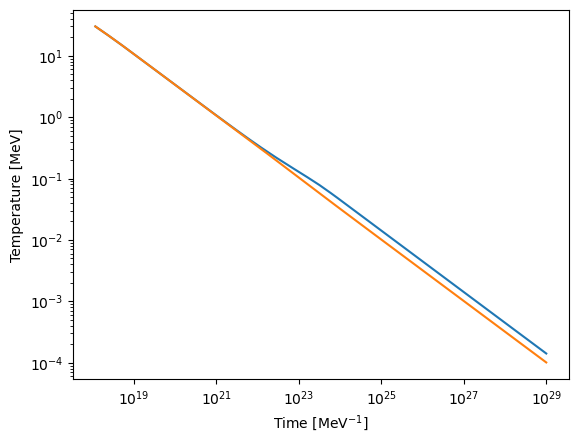

In [45]:
plt.plot(time_sm, T_gam_sm)
plt.plot(time_sm, T_nu_sm)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')
plt.ylabel('Temperature [MeV]')

plt.show()

In [46]:
sol_bsm = Boltz.solve_boltzmann_eq(T_gamma_0, T_nu_0, T_DS_0)

time_bsm = sol_bsm[0]
T_gam_bsm = sol_bsm[1]
T_nu_bsm = sol_bsm[2]
T_dark_bsm = sol_bsm[3]
sf_bsm = sol_bsm[4]

## Neff

In [47]:
T_dark_bsm[-1]/T_gam_bsm[-1]

1.004624283744253

In [48]:
N_eff_sm = Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1])
N_eff_bsm = Boltz.N_eff(T_gam_bsm[-1], T_nu_bsm[-1], T_dark_bsm[-1])

Delta_Neff = N_eff_bsm - N_eff_sm 
Delta_Neff_Dso = Boltz.Delta_Neff_ds_only(T_gam_bsm[-1],  T_dark_bsm[-1])

In [49]:
print(f'{N_eff_sm=}')
print(f'{N_eff_bsm=}')
print(f'{Delta_Neff=}')
print(f'{Delta_Neff_Dso=}')

N_eff_sm=3.0222526143177686
N_eff_bsm=array([7.52102979])
Delta_Neff=array([4.49877717])
Delta_Neff_Dso=array([4.48521803])


In [50]:
print(f'{T_dark_bsm[-1]/T_gam_bsm[-1]=}')
print(f'{T_nu_bsm[-1]/T_gam_bsm[-1]=}')

print(f'{T_gam_bsm[-1]/T_gam_sm[-1]=}')

T_dark_bsm[-1]/T_gam_bsm[-1]=1.004624283744253
T_nu_bsm[-1]/T_gam_bsm[-1]=0.7158864870260153
T_gam_bsm[-1]/T_gam_sm[-1]=0.8883482802903934


## Temperature Evolution

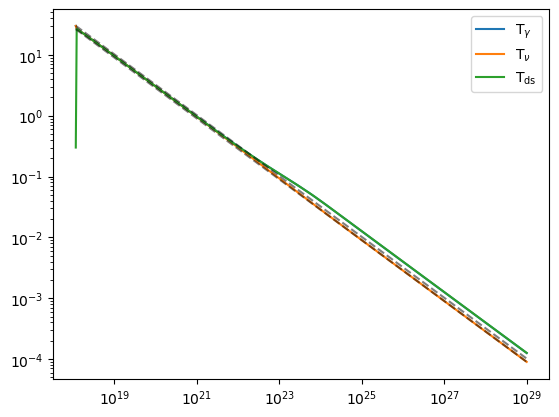

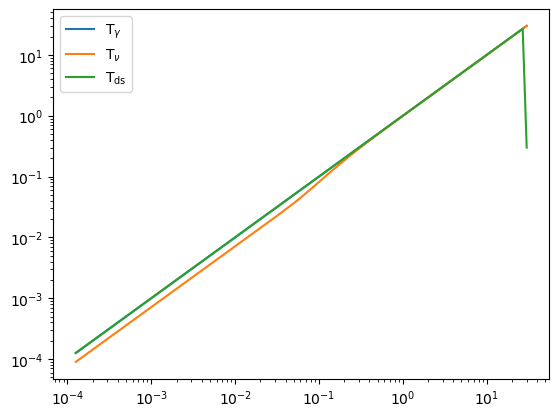

In [38]:
plt.plot(time_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(time_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(time_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')

plt.plot(time_bsm, T_gam_bsm[0]*np.sqrt(time_bsm[0]/time_bsm), linestyle='dashed', color='black', alpha=0.5)
plt.plot(time_bsm, T_nu_bsm[-1]*np.sqrt(time_bsm[-1]/time_bsm), linestyle='dashed', color='black', alpha=0.5)

plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


plt.plot(T_gam_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(T_gam_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(T_gam_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')


plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


In [39]:
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_left_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_right_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig4_left_Td_by_Tgam.csv')
fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig4_right_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Td_by_Tgam.csv')

fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig4_right_Tnu_by_Tgam.csv')
# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Tnu_by_Tgam.csv')
# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Tnu_by_Tgam.csv')

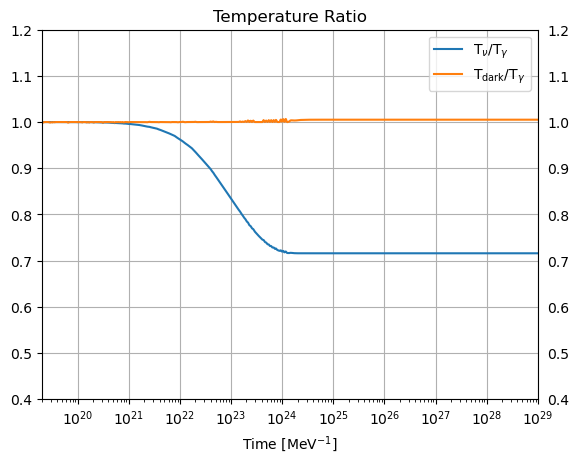

In [42]:
plt.plot(time_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(time_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
plt.xscale('log')
# plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')
plt.title('Temperature Ratio')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')

plt.legend()

plt.xlim(2e19, 1e29)
plt.ylim(0.4, 1.2)

plt.show()



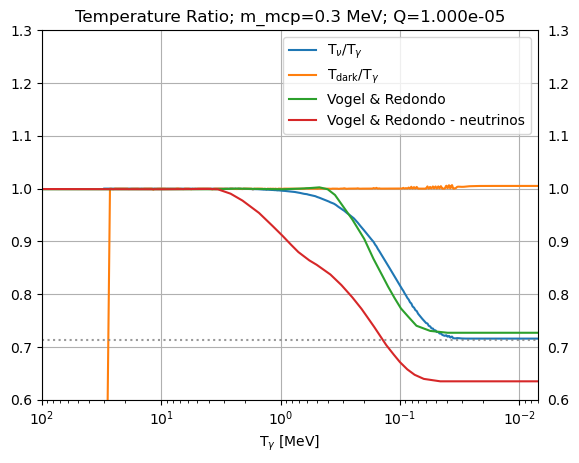

In [41]:
plt.plot(T_gam_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(T_gam_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
plt.plot(*fig3_1311_2600_Td_by_Tgam, label='Vogel & Redondo')
plt.plot(*fig3_1311_2600_Tnu_by_Tgam, label='Vogel & Redondo - neutrinos')
plt.xscale('log')
# plt.yscale('log')

plt.xlabel('T$_\gamma$ [MeV]')
plt.title(f'Temperature Ratio; {m_mcp=} MeV; {Q=:.3e}')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')
plt.gca().invert_xaxis()


plt.ylim(0.6, 1.3)
# plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
# plt.axvline(150,  color='purple', linestyle='dashed', alpha=0.5)

plt.axhline((4/11)**(1/3), alpha=0.8, color='gray', linestyle='dotted')


plt.xlim(1e2, 7e-3)

plt.legend()

# plt.savefig('../output/figures/temp_ratio/VR_fig4_right_comparison.png')
plt.show()

In [ ]:
Col_tot = (
    CF_ann_sm_ds(T_gam_bsm, T_dark_bsm, Q)
   +CF_plas(T_gam_bsm, T_dark_bsm, Q)
)

Hub_tot = boltzmann.Hubble(T_gam_bsm, T_nu_bsm,T_dark_bsm, m_mcp)*(
    boltzmann.rho_DS(T_dark_bsm, m_mcp) + boltzmann.p_DS(T_dark_bsm, m_mcp)
)
            

In [ ]:
com_ED = boltzmann.rho_DS(T_dark_bsm, m_mcp)*(sf_bsm)**4
# com_col = Boltz.colterm_EM_DS(T_gam_bsm, T_dark_bsm)*(sol_bsm.y[3])**4
# com_col = CF_ann(T_gam_bsm, Q)*(sol_bsm.y[3])**4
# com_col = (
#     CF_scatt_sm_ds_F(T_gam_bsm, T_dark_bsm, Q)
#    +CF_ann(T_gam_bsm, Q)
#    +plas.C_plasmon_forwards(T_gam_bsm, m_mcp, Q)
# )*(sf_bsm)**4

com_col = (
   +CF_ann(T_gam_bsm, Q)
   +plas.C_plasmon_forwards(T_gam_bsm, m_mcp, Q)
)*(sf_bsm)**4

H_plot = Hubble(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)

In [ ]:
# shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_left_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_right_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

## We need to plot the forward energy transfer term here, which needs to be computed for elastic scattering

In [ ]:
#compute comoving energy density for DeltaNeff = 0.3s

In [ ]:
#calculation of dark sector temp that makes Delta N_eff = 0.3 at Tsm = 1e-3 MeV
r = 0.3*(7/8)*(4/11)**(4/3)*boltzmann.rho_EM(1e-3)
T_ds_03 = ((15/np.pi**2)*r)**(1/4)

sf = sf_bsm[find_nearest(T_gam_bsm, 1e-3)]

rho_neff_03 = boltzmann.rho_DS(T_ds_03, m_mcp)*(sf)**4

In [ ]:
plt.plot(T_gam_bsm, com_ED)
plt.plot(T_gam_bsm, com_col/H_plot)
plt.plot(*shelton_f2_rho)
# plt.plot(*shelton_f2_cF)

plt.axhline(rho_neff_03, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed')
plt.axhline(1.3e-40, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed', color='gray')

plt.yscale('log')
plt.xscale('log')
plt.axvline(m_mcp/4, linestyle='dashed', color='black')

plt.xlabel(r'T$_{\rm sm}$ [MeV]')
plt.ylabel(r'$\rho_{\rm hs} a^4$')

plt.ylim(1e-42, 1e-39)
# plt.xlim(3, 1e4)
plt.xlim(10, 2e6)
plt.show()

In [ ]:
rho_test = com_ED[find_nearest(T_gam_bsm, 2e3)]/sf_bsm[find_nearest(T_gam_bsm, 2e3)]**4

In [ ]:
rho_DS(T_gam_bsm[find_nearest(T_gam_bsm, 2e3)], m_mcp)

In [ ]:
rho_test/rho_DS(T_gam_bsm[find_nearest(T_gam_bsm, 2e3)], m_mcp)

In [ ]:
T_dark_bsm[find_nearest(T_gam_bsm, 2e3)]

In [ ]:
plt.plot(T_gam_bsm, sf_bsm, alpha=)
plt.plot(T_gam_sm, sf_sm, alpha=0.4)


plt.yscale('log')
plt.xscale('log')

In [ ]:
plt.plot(T_gam_bsm, sf_bsm)
plt.yscale('log')
plt.xscale('log')
plt.show()

plt.plot(T_gam_bsm, CF_ann(T_gam_bsm, Q))
plt.yscale('log')
plt.xscale('log')
plt.show()

plt.plot(T_gam_bsm, CF_ann(T_gam_bsm, Q)*sf_bsm**4/H_plot)
plt.plot(T_gam_bsm, CF_scatt_sm_ds_F(T_gam_bsm, T_dark_bsm, Q)*sf_bsm**4/H_plot)
plt.plot(T_gam_bsm, plas.C_plasmon_forwards(T_gam_bsm, m_mcp, Q)*sf_bsm**4/H_plot)
plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-41, 1e-35)
plt.show()




In [ ]:
rho_tot_bsm = boltzmann.rho_tot_bsm(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)

In [ ]:
rho_dot = np.nan_to_num(np.gradient(rho_tot_bsm, time_bsm, edge_order=2))

In [ ]:
cont = -3*boltzmann.Hubble(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)*(
    boltzmann.rho_tot_bsm(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)
  + boltzmann.p_tot_bsm(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)
)

In [ ]:
rho_tot_sm = boltzmann.rho_tot_sm(T_gam_sm, T_nu_sm)
cont_sm = -3*boltzmann.Hubble_SM(T_gam_sm, T_nu_sm)*(
    boltzmann.rho_tot_sm(T_gam_sm, T_nu_sm)
  + boltzmann.p_tot_sm(T_gam_sm, T_nu_sm)
)

rho_dot_sm = np.gradient(rho_tot_sm, time_sm)

## Check Continuity

In [ ]:
rho_dot_sm/cont_sm

In [ ]:
rho_dot/cont